In [4]:
!pip install scikit-surprise

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 29.2 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from surprise import SVD, Dataset, Reader

import matplotlib.pyplot as plt

In [6]:
import os

print(os.listdir('/content'))

['.config', 'ratings.dat', 'movies.dat', 'sample_data']


In [7]:
ratings = pd.read_csv(
    '/content/ratings.dat',
    sep='::',
    engine='python',
    names=['userId', 'movieId', 'rating', 'timestamp']
)

ratings.head()

,userId,movieId,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [8]:
ratings.shape

(557248, 4)

In [9]:
movies = pd.read_csv(
    '/content/movies.dat',
    sep='::',
    engine='python',
    names=['movieId', 'title', 'genres'],
    encoding='latin-1'
)

movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [10]:
print("Number of ratings:", len(ratings))
print("Number of users:", ratings['userId'].nunique())
print("Number of movies:", ratings['movieId'].nunique())

Number of ratings: 557248
Number of users: 3423
Number of movies: 3629


In [11]:
ratings['rating'].value_counts().sort_index()

,count
rating,
1,31264
2,61012
3,144571
4,194999
5,125402


In [12]:
reader = Reader(rating_scale=(1, 5))

data = Dataset.load_from_df(
    ratings[['userId', 'movieId', 'rating']],
    reader
)

In [13]:
trainset = data.build_full_trainset()

In [14]:
svd = SVD(
    n_factors=100,
    n_epochs=20,
    random_state=42
)

svd.fit(trainset)

In [15]:
prediction = svd.predict(1, 50)

print(prediction.est)

4.5910304417690995


In [16]:
movies['genres'] = movies['genres'].str.replace('|', ' ', regex=False)

In [17]:
tfidf = TfidfVectorizer()

tfidf_matrix = tfidf.fit_transform(movies['genres'])

In [18]:
content_similarity = cosine_similarity(tfidf_matrix)

In [19]:
def get_similar_movies(movie_id, top_n=10):

    movie_index = movies.index[
        movies['movieId'] == movie_id
    ][0]

    similarity_scores = content_similarity[movie_index]

    similar_indices = similarity_scores.argsort()[-top_n-1:-1][::-1]

    return movies.iloc[similar_indices][['movieId', 'title', 'genres']]

In [20]:
get_similar_movies(1, 10)

,movieId,title,genres
3542,3611,Saludos Amigos (1943),Animation Children's Comedy
3045,3114,Toy Story 2 (1999),Animation Children's Comedy
2073,2142,"American Tail: Fievel Goes West, An (1991)",Animation Children's Comedy
3682,3751,Chicken Run (2000),Animation Children's Comedy
0,1,Toy Story (1995),Animation Children's Comedy
2072,2141,"American Tail, An (1986)",Animation Children's Comedy
2286,2355,"Bug's Life, A (1998)",Animation Children's Comedy
1050,1064,Aladdin and the King of Thieves (1996),Animation Children's Comedy
3685,3754,"Adventures of Rocky and Bullwinkle, The (2000)",Animation Children's Comedy
310,313,"Swan Princess, The (1994)",Animation Children's


In [21]:
def get_cf_weight(num_interactions, c=5):
    return num_interactions / (num_interactions + c)

In [22]:
for n in [0, 1, 2, 5, 10, 20, 50]:
    print(n, get_cf_weight(n))

0 0.0
1 0.16666666666666666
2 0.2857142857142857
5 0.5
10 0.6666666666666666
20 0.8
50 0.9090909090909091


In [23]:
user_counts = ratings.groupby('userId').size()

cold_users = user_counts[user_counts < 5].index

warm_users = user_counts[user_counts >= 5].index

print("Cold users:", len(cold_users))
print("Warm users:", len(warm_users))

Cold users: 0
Warm users: 3423


In [24]:
from sklearn.model_selection import train_test_split

train_ratings, test_ratings = train_test_split(
    ratings,
    test_size=0.2,
    random_state=42
)

print("Training ratings:", len(train_ratings))
print("Testing ratings:", len(test_ratings))

Training ratings: 445798
Testing ratings: 111450


In [25]:
reader = Reader(rating_scale=(1, 5))

train_data = Dataset.load_from_df(
    train_ratings[['userId', 'movieId', 'rating']],
    reader
)

trainset = train_data.build_full_trainset()

svd = SVD(
    n_factors=100,
    n_epochs=20,
    random_state=42
)

svd.fit(trainset)

print("SVD training completed!")

SVD training completed!


In [26]:
user_interactions = train_ratings.groupby('userId').size()

user_interactions.head()

,0
userId,
1,43
2,100
3,43
4,20
5,158


In [27]:
def get_cf_weight(num_interactions):
    return num_interactions / (num_interactions + 5)

In [28]:
for n in [0, 1, 2, 3, 4, 5, 10, 20, 50, 100]:
    print(
        "Interactions:", n,
        "CF weight:", round(get_cf_weight(n), 2),
        "Content weight:", round(1 - get_cf_weight(n), 2)
    )

Interactions: 0 CF weight: 0.0 Content weight: 1.0
Interactions: 1 CF weight: 0.17 Content weight: 0.83
Interactions: 2 CF weight: 0.29 Content weight: 0.71
Interactions: 3 CF weight: 0.38 Content weight: 0.62
Interactions: 4 CF weight: 0.44 Content weight: 0.56
Interactions: 5 CF weight: 0.5 Content weight: 0.5
Interactions: 10 CF weight: 0.67 Content weight: 0.33
Interactions: 20 CF weight: 0.8 Content weight: 0.2
Interactions: 50 CF weight: 0.91 Content weight: 0.09
Interactions: 100 CF weight: 0.95 Content weight: 0.05


In [29]:
movie_index = pd.Series(
    movies.index,
    index=movies['movieId']
).drop_duplicates()

In [30]:
def get_content_score(user_id, movie_id):

    # Movies the user rated highly
    user_history = train_ratings[
        (train_ratings['userId'] == user_id) &
        (train_ratings['rating'] >= 4)
    ]

    # If user has no history
    if len(user_history) == 0:
        return 0

    # Check whether movie exists
    if movie_id not in movie_index:
        return 0

    movie_idx = movie_index[movie_id]

    scores = []

    for liked_movie in user_history['movieId']:

        if liked_movie not in movie_index:
            continue

        liked_idx = movie_index[liked_movie]

        similarity = content_similarity[
            liked_idx,
            movie_idx
        ]

        scores.append(similarity)

    if len(scores) == 0:
        return 0

    return np.mean(scores)

In [31]:
def get_cf_score(user_id, movie_id):

    prediction = svd.predict(user_id, movie_id)

    score = prediction.est

    # Convert 1-5 rating to 0-1
    score = (score - 1) / 4

    return score

In [32]:
def get_hybrid_score(user_id, movie_id):

    # Number of interactions
    num_interactions = user_interactions.get(user_id, 0)

    # Dynamic CF weight
    cf_weight = get_cf_weight(num_interactions)

    # Content weight
    content_weight = 1 - cf_weight

    # Scores
    cf_score = get_cf_score(user_id, movie_id)

    content_score = get_content_score(
        user_id,
        movie_id
    )

    # Final score
    hybrid_score = (
        cf_weight * cf_score
        +
        content_weight * content_score
    )

    return hybrid_score

In [33]:
user_id = 1
movie_id = 50

score = get_hybrid_score(
    user_id,
    movie_id
)

print("Hybrid score:", score)

Hybrid score: 0.8421949894142274


In [34]:
def recommend_movies(user_id, top_n=10):

    # Movies already watched by user
    watched_movies = set(
        train_ratings[
            train_ratings['userId'] == user_id
        ]['movieId']
    )

    # Candidate movies
    candidate_movies = movies[
        ~movies['movieId'].isin(watched_movies)
    ]

    recommendations = []

    for movie_id in candidate_movies['movieId']:

        score = get_hybrid_score(
            user_id,
            movie_id
        )

        recommendations.append(
            (movie_id, score)
        )

    # Sort by score
    recommendations.sort(
        key=lambda x: x[1],
        reverse=True
    )

    # Top N
    top_movies = recommendations[:top_n]

    result = []

    for movie_id, score in top_movies:

        movie_title = movies[
            movies['movieId'] == movie_id
        ]['title'].values[0]

        result.append({
            'movieId': movie_id,
            'title': movie_title,
            'score': score
        })

    return pd.DataFrame(result)

In [35]:
recommend_movies(1, 10)

,movieId,title,score
0,1148,"Wrong Trousers, The (1993)",0.908158
1,2571,"Matrix, The (1999)",0.898674
2,306,Three Colors: Red (1994),0.894238
3,2858,American Beauty (1999),0.873480
4,2905,Sanjuro (1962),0.872844
5,3469,Inherit the Wind (1960),0.859794
6,904,Rear Window (1954),0.859167
7,2019,Seven Samurai (The Magnificent Seven) (Shichin...,0.858343
8,3629,"Gold Rush, The (1925)",0.856958
9,1203,12 Angry Men (1957),0.856846


In [36]:
cold_users
warm_users

Index([   1,    2,    3,    4,    5,    6,    7,    8,    9,   10,
       ...
       3414, 3415, 3416, 3417, 3418, 3419, 3420, 3421, 3422, 3423],
      dtype='int64', name='userId', length=3423)

In [44]:
print("Number of cold users:", len(cold_users))
print("Number of warm users:", len(warm_users))

Number of cold users: 0
Number of warm users: 3423


In [48]:
user_counts.describe()

,0
count,3423.000000
mean,162.795209
std,191.832997
min,20.000000
25%,43.000000
50%,90.000000
75%,202.000000
max,1850.000000


In [49]:
print(user_counts.min())
print(user_counts.max())

20
1850


In [50]:
# Number of interactions each user has
user_counts = train_ratings.groupby('userId').size()

print("Minimum interactions:", user_counts.min())
print("Maximum interactions:", user_counts.max())

Minimum interactions: 10
Maximum interactions: 1483


In [51]:
# Select users who have at least 10 ratings
user_counts = ratings.groupby('userId').size()

eligible_users = user_counts[user_counts >= 10].index

# Select 100 users for cold-start testing
np.random.seed(42)
cold_user_ids = np.random.choice(
    eligible_users,
    size=100,
    replace=False
)

print("Number of cold-start users:", len(cold_user_ids))

Number of cold-start users: 100


In [52]:
cold_histories = {}
cold_test = {}

for user_id in cold_user_ids:

    user_data = ratings[
        ratings['userId'] == user_id
    ].sample(frac=1, random_state=42)

    # Only 3 ratings are visible to the recommender
    known = user_data.head(3)

    # Remaining ratings are hidden for evaluation
    hidden = user_data.iloc[3:]

    cold_histories[user_id] = known
    cold_test[user_id] = hidden

print("Cold-start history created.")

Cold-start history created.


In [53]:
example_user = cold_user_ids[0]

print("User ID:", example_user)

print("\nKnown ratings:")
print(cold_histories[example_user])

print("\nHidden ratings:")
print(cold_test[example_user].head())

User ID: 791

Known ratings:
        userId  movieId  rating  timestamp
122670     791     3528       3  982854757
122549     791     3489       3  981767635
122689     791     3705       2  982159810

Hidden ratings:
        userId  movieId  rating   timestamp
122448     791      586       4  1010160826
122532     791     2640       4   981767814
122659     791     2571       5   975424551
122748     791     1073       4   981767573
122638     791     3176       4   975424677


In [54]:
def get_cold_content_score(user_id, movie_id):

    # Get the 3 movies visible to this cold user
    user_history = cold_histories[user_id]

    # Only use movies the user rated 4 or 5
    liked_movies = user_history[
        user_history['rating'] >= 4
    ]['movieId']

    if len(liked_movies) == 0:
        return 0

    if movie_id not in movie_index:
        return 0

    movie_idx = movie_index[movie_id]

    scores = []

    for liked_movie in liked_movies:

        if liked_movie not in movie_index:
            continue

        liked_idx = movie_index[liked_movie]

        similarity = content_similarity[
            liked_idx,
            movie_idx
        ]

        scores.append(similarity)

    if len(scores) == 0:
        return 0

    return np.mean(scores)

In [55]:
def recommend_cold_user(user_id, top_n=10):

    # Movies already known to the user
    known_movies = set(
        cold_histories[user_id]['movieId']
    )

    # Don't recommend already known movies
    candidate_movies = movies[
        ~movies['movieId'].isin(known_movies)
    ]

    recommendations = []

    for movie_id in candidate_movies['movieId']:

        score = get_cold_content_score(
            user_id,
            movie_id
        )

        recommendations.append(
            (movie_id, score)
        )

    # Highest score first
    recommendations.sort(
        key=lambda x: x[1],
        reverse=True
    )

    top_movies = recommendations[:top_n]

    result = []

    for movie_id, score in top_movies:

        movie_title = movies[
            movies['movieId'] == movie_id
        ]['title'].values[0]

        result.append({
            'movieId': movie_id,
            'title': movie_title,
            'score': score
        })

    return pd.DataFrame(result)

In [56]:
example_user = cold_user_ids[0]

cold_recommendations = recommend_cold_user(
    example_user,
    top_n=10
)

cold_recommendations

,movieId,title,score
0,1,Toy Story (1995),0
1,2,Jumanji (1995),0
2,3,Grumpier Old Men (1995),0
3,4,Waiting to Exhale (1995),0
4,5,Father of the Bride Part II (1995),0
5,6,Heat (1995),0
6,7,Sabrina (1995),0
7,8,Tom and Huck (1995),0
8,9,Sudden Death (1995),0
9,10,GoldenEye (1995),0


In [57]:
def get_relevant_movies(user_id):

    hidden_ratings = cold_test[user_id]

    relevant = hidden_ratings[
        hidden_ratings['rating'] >= 4
    ]['movieId'].tolist()

    return relevant

In [58]:
relevant_movies = get_relevant_movies(example_user)

print("Relevant movies:", relevant_movies)

Relevant movies: [586, 2640, 2571, 1073, 3176, 110, 3462, 2023, 1198, 2126, 648, 1270, 3404, 3044, 1200, 2641, 708, 3635, 3499, 1022, 1380, 3753, 1376, 2406, 1288, 2161, 1370, 2000, 1101, 1374, 1214, 2616, 1207, 1265, 3256, 1258, 3255, 2003, 2001, 1377, 2054, 1019, 1466, 3809, 2176, 2193, 597, 2881, 1921, 3254, 2716, 2109, 1569, 457, 3629, 34, 1333, 1345, 2366, 931, 3751, 2997, 2081, 595, 376, 2761, 2407, 1918, 2100, 1747, 1438, 3524, 1197, 1042, 2145, 1920, 2118, 3070, 1580, 590, 368, 3742, 592, 2455, 2717, 1344, 3448, 3948, 2687, 587, 1393, 2291, 596, 904, 1943, 1617, 3712, 2396, 858, 1674, 515, 50, 1321, 1204, 3578, 11, 141, 1136, 2094, 2723, 2518, 1221, 1888, 2371, 2013, 2028, 2947, 1387, 1032, 380, 2991, 1517, 1588, 349, 1994, 3671, 3253, 2080, 1663, 45, 260, 2194, 1777, 2762, 1210, 1784, 2470, 1394, 589, 903, 3022, 2115, 3175, 920, 3555, 440, 1294, 208, 1023, 480, 2078, 1093, 1307, 2987, 3745, 2791, 539, 3608, 2792, 3361, 1291, 661, 2243, 364, 588, 1097, 1278, 3798, 2087, 1017, 3

In [59]:
def precision_at_k(recommended, relevant, k=10):

    recommended = recommended[:k]
    relevant = set(relevant)

    if len(recommended) == 0:
        return 0

    hits = len(
        set(recommended) & relevant
    )

    return hits / k

In [60]:
def recall_at_k(recommended, relevant, k=10):

    recommended = recommended[:k]
    relevant = set(relevant)

    if len(relevant) == 0:
        return 0

    hits = len(
        set(recommended) & relevant
    )

    return hits / len(relevant)

In [61]:
def ndcg_at_k(recommended, relevant, k=10):

    recommended = recommended[:k]
    relevant = set(relevant)

    dcg = 0

    for i, movie_id in enumerate(recommended, start=1):

        if movie_id in relevant:
            dcg += 1 / np.log2(i + 1)

    ideal_hits = min(len(relevant), k)

    if ideal_hits == 0:
        return 0

    idcg = sum(
        1 / np.log2(i + 1)
        for i in range(1, ideal_hits + 1)
    )

    return dcg / idcg

In [62]:
recommended_movies = cold_recommendations['movieId'].tolist()

precision = precision_at_k(
    recommended_movies,
    relevant_movies,
    k=10
)

recall = recall_at_k(
    recommended_movies,
    relevant_movies,
    k=10
)

ndcg = ndcg_at_k(
    recommended_movies,
    relevant_movies,
    k=10
)

print("Precision@10:", precision)
print("Recall@10:", recall)
print("NDCG@10:", ndcg)

Precision@10: 0.1
Recall@10: 0.0041841004184100415
NDCG@10: 0.22009176629808017


In [63]:
cold_results = []

for user_id in cold_user_ids:

    recommendations = recommend_cold_user(
        user_id,
        top_n=10
    )

    recommended_movies = recommendations[
        'movieId'
    ].tolist()

    relevant_movies = get_relevant_movies(
        user_id
    )

    if len(relevant_movies) == 0:
        continue

    precision = precision_at_k(
        recommended_movies,
        relevant_movies,
        k=10
    )

    recall = recall_at_k(
        recommended_movies,
        relevant_movies,
        k=10
    )

    ndcg = ndcg_at_k(
        recommended_movies,
        relevant_movies,
        k=10
    )

    cold_results.append({
        'userId': user_id,
        'precision@10': precision,
        'recall@10': recall,
        'ndcg@10': ndcg
    })

cold_results = pd.DataFrame(cold_results)

cold_results.head()

,userId,precision@10,recall@10,ndcg@10
0,791,0.1,0.004184,0.220092
1,2425,0.0,0.000000,0.000000
2,2079,0.1,0.019608,0.069431
3,1053,0.3,0.018868,0.453743
4,444,0.4,0.043956,0.341819


In [64]:
print(
    "Average Precision@10:",
    cold_results['precision@10'].mean()
)

print(
    "Average Recall@10:",
    cold_results['recall@10'].mean()
)

print(
    "Average NDCG@10:",
    cold_results['ndcg@10'].mean()
)

Average Precision@10: 0.07200000000000001
Average Recall@10: 0.010309295243184989
Average NDCG@10: 0.07277934716091737


In [65]:
movie_popularity = ratings.groupby('movieId').size()

max_popularity = movie_popularity.max()

def get_popularity_score(movie_id):

    count = movie_popularity.get(movie_id, 0)

    return count / max_popularity

In [66]:
def get_cold_hybrid_score(user_id, movie_id):

    # Number of interactions visible to the model
    num_interactions = len(
        cold_histories[user_id]
    )

    # Dynamic weights
    cf_weight = get_cf_weight(num_interactions)
    content_weight = 1 - cf_weight

    # Content score
    content_score = get_cold_content_score(
        user_id,
        movie_id
    )

    # Popularity acts as CF fallback for cold users
    cf_score = get_popularity_score(
        movie_id
    )

    # Hybrid score
    hybrid_score = (
        cf_weight * cf_score
        +
        content_weight * content_score
    )

    return hybrid_score

In [67]:
def recommend_cold_hybrid(user_id, top_n=10):

    known_movies = set(
        cold_histories[user_id]['movieId']
    )

    candidate_movies = movies[
        ~movies['movieId'].isin(known_movies)
    ]

    recommendations = []

    for movie_id in candidate_movies['movieId']:

        score = get_cold_hybrid_score(
            user_id,
            movie_id
        )

        recommendations.append(
            (movie_id, score)
        )

    recommendations.sort(
        key=lambda x: x[1],
        reverse=True
    )

    top_movies = recommendations[:top_n]

    result = []

    for movie_id, score in top_movies:

        title = movies[
            movies['movieId'] == movie_id
        ]['title'].values[0]

        result.append({
            'movieId': movie_id,
            'title': title,
            'score': score
        })

    return pd.DataFrame(result)

In [68]:
example_user = cold_user_ids[0]

hybrid_recommendations = recommend_cold_hybrid(
    example_user,
    top_n=10
)

hybrid_recommendations

,movieId,title,score
0,2858,American Beauty (1999),0.375000
1,260,Star Wars: Episode IV - A New Hope (1977),0.308671
2,1196,Star Wars: Episode V - The Empire Strikes Back...,0.304595
3,480,Jurassic Park (1993),0.297184
4,1210,Star Wars: Episode VI - Return of the Jedi (1983),0.296257
5,589,Terminator 2: Judgment Day (1991),0.290884
6,2028,Saving Private Ryan (1998),0.281991
7,1580,Men in Black (1997),0.275692
8,110,Braveheart (1995),0.273283
9,2571,"Matrix, The (1999)",0.270133


In [69]:
cold_hybrid_results = []

for user_id in cold_user_ids:

    recommendations = recommend_cold_hybrid(
        user_id,
        top_n=10
    )

    recommended_movies = recommendations[
        'movieId'
    ].tolist()

    relevant_movies = get_relevant_movies(
        user_id
    )

    if len(relevant_movies) == 0:
        continue

    precision = precision_at_k(
        recommended_movies,
        relevant_movies,
        k=10
    )

    recall = recall_at_k(
        recommended_movies,
        relevant_movies,
        k=10
    )

    ndcg = ndcg_at_k(
        recommended_movies,
        relevant_movies,
        k=10
    )

    cold_hybrid_results.append({
        'userId': user_id,
        'precision@10': precision,
        'recall@10': recall,
        'ndcg@10': ndcg
    })

cold_hybrid_results = pd.DataFrame(
    cold_hybrid_results
)

cold_hybrid_results.head()

,userId,precision@10,recall@10,ndcg@10
0,791,0.9,0.037657,0.779908
1,2425,0.4,0.125000,0.288382
2,2079,0.4,0.078431,0.542364
3,1053,0.7,0.044025,0.775337
4,444,0.6,0.065934,0.665291


In [70]:
cold_hybrid_precision = cold_hybrid_results[
    'precision@10'
].mean()

cold_hybrid_recall = cold_hybrid_results[
    'recall@10'
].mean()

cold_hybrid_ndcg = cold_hybrid_results[
    'ndcg@10'
].mean()

print("Cold-start Hybrid Performance")
print("--------------------------------")
print("Precision@10:", cold_hybrid_precision)
print("Recall@10:", cold_hybrid_recall)
print("NDCG@10:", cold_hybrid_ndcg)

Cold-start Hybrid Performance
--------------------------------
Precision@10: 0.304
Recall@10: 0.0658043839751404
NDCG@10: 0.32963295770359125


In [71]:
comparison = pd.DataFrame({
    'Model': [
        'Content-Based',
        'Hybrid'
    ],

    'Precision@10': [
        cold_results['precision@10'].mean(),
        cold_hybrid_results['precision@10'].mean()
    ],

    'Recall@10': [
        cold_results['recall@10'].mean(),
        cold_hybrid_results['recall@10'].mean()
    ],

    'NDCG@10': [
        cold_results['ndcg@10'].mean(),
        cold_hybrid_results['ndcg@10'].mean()
    ]
})

comparison

,Model,Precision@10,Recall@10,NDCG@10
0,Content-Based,0.072,0.010309,0.072779
1,Hybrid,0.304,0.065804,0.329633


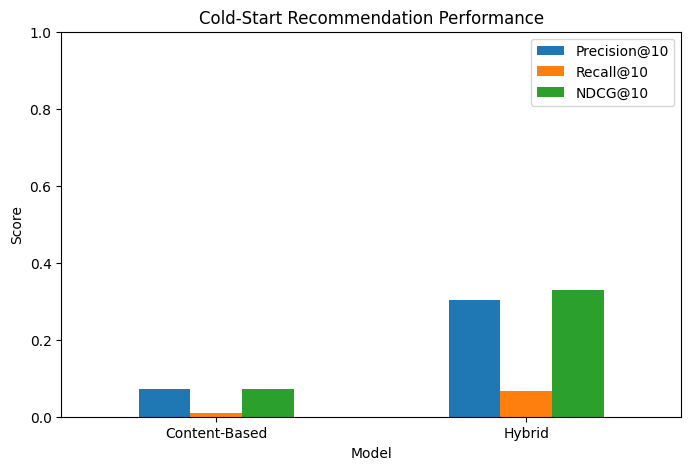

In [72]:
comparison.set_index('Model').plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Cold-Start Recommendation Performance')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

In [73]:
warm_user_counts = train_ratings.groupby('userId').size()

warm_user_ids = warm_user_counts[
    warm_user_counts >= 5
].index

np.random.seed(42)

warm_user_ids = np.random.choice(
    warm_user_ids,
    size=100,
    replace=False
)

print("Number of warm users:", len(warm_user_ids))

Number of warm users: 100


In [74]:
warm_results = []

for user_id in warm_user_ids:

    recommendations = recommend_movies(
        user_id,
        top_n=10
    )

    recommended_movies = recommendations[
        'movieId'
    ].tolist()

    # Movies from test set that the user liked
    relevant_movies = test_ratings[
        (test_ratings['userId'] == user_id) &
        (test_ratings['rating'] >= 4)
    ]['movieId'].tolist()

    if len(relevant_movies) == 0:
        continue

    precision = precision_at_k(
        recommended_movies,
        relevant_movies,
        k=10
    )

    recall = recall_at_k(
        recommended_movies,
        relevant_movies,
        k=10
    )

    ndcg = ndcg_at_k(
        recommended_movies,
        relevant_movies,
        k=10
    )

    warm_results.append({
        'userId': user_id,
        'precision@10': precision,
        'recall@10': recall,
        'ndcg@10': ndcg
    })

warm_results = pd.DataFrame(warm_results)

warm_results.head()

,userId,precision@10,recall@10,ndcg@10
0,791,0.1,0.019231,0.063621
1,2425,0.0,0.000000,0.000000
2,2079,0.1,0.083333,0.220092
3,1053,0.1,0.025641,0.220092
4,444,0.0,0.000000,0.000000


In [75]:
warm_precision = warm_results[
    'precision@10'
].mean()

warm_recall = warm_results[
    'recall@10'
].mean()

warm_ndcg = warm_results[
    'ndcg@10'
].mean()

print("Warm User Performance")
print("----------------------")
print("Precision@10:", warm_precision)
print("Recall@10:", warm_recall)
print("NDCG@10:", warm_ndcg)

Warm User Performance
----------------------
Precision@10: 0.07700000000000001
Recall@10: 0.067495685186423
NDCG@10: 0.11024615614976926


In [76]:
cold_hybrid_precision
cold_hybrid_recall
cold_hybrid_ndcg

np.float64(0.32963295770359125)

In [77]:
warm_precision
warm_recall
warm_ndcg

np.float64(0.11024615614976926)

In [78]:
final_results = pd.DataFrame({
    'User Type': [
        'Cold-start (<5 interactions)',
        'Warm (≥5 interactions)'
    ],

    'Precision@10': [
        cold_hybrid_precision,
        warm_precision
    ],

    'Recall@10': [
        cold_hybrid_recall,
        warm_recall
    ],

    'NDCG@10': [
        cold_hybrid_ndcg,
        warm_ndcg
    ]
})

final_results

,User Type,Precision@10,Recall@10,NDCG@10
0,Cold-start (<5 interactions),0.304,0.065804,0.329633
1,Warm (≥5 interactions),0.077,0.067496,0.110246


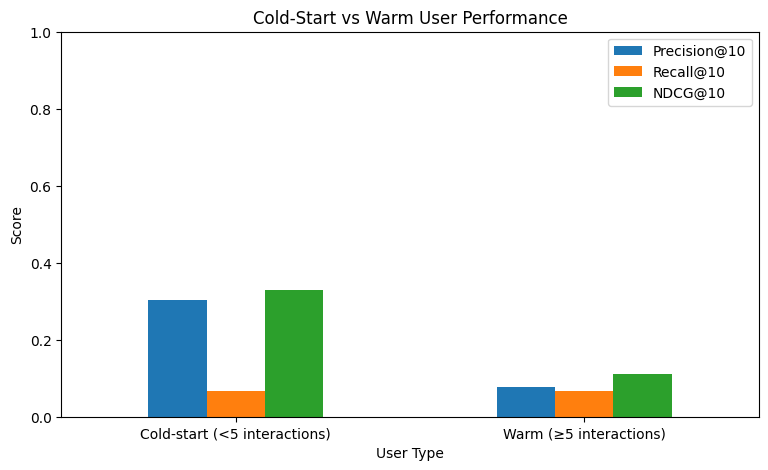

In [79]:
final_results.set_index(
    'User Type'
).plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title(
    'Cold-Start vs Warm User Performance'
)

plt.ylabel('Score')

plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.show()

In [80]:
interaction_values = [0, 1, 2, 3, 5, 10, 20, 50, 100]

weights = []

for n in interaction_values:

    cf_weight = get_cf_weight(n)

    content_weight = 1 - cf_weight

    weights.append({
        'Interactions': n,
        'CF Weight': cf_weight,
        'Content Weight': content_weight
    })

weight_table = pd.DataFrame(weights)

weight_table

,Interactions,CF Weight,Content Weight
0,0,0.000000,1.000000
1,1,0.166667,0.833333
2,2,0.285714,0.714286
3,3,0.375000,0.625000
4,5,0.500000,0.500000
5,10,0.666667,0.333333
6,20,0.800000,0.200000
7,50,0.909091,0.090909
8,100,0.952381,0.047619


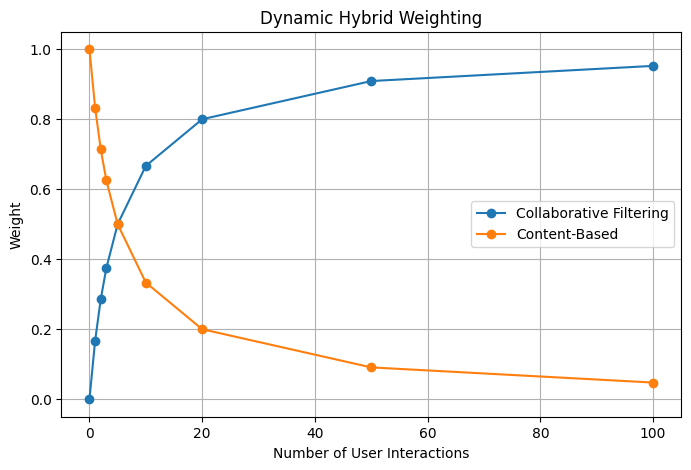

In [81]:
plt.figure(figsize=(8, 5))

plt.plot(
    interaction_values,
    weight_table['CF Weight'],
    marker='o',
    label='Collaborative Filtering'
)

plt.plot(
    interaction_values,
    weight_table['Content Weight'],
    marker='o',
    label='Content-Based'
)

plt.xlabel('Number of User Interactions')

plt.ylabel('Weight')

plt.title(
    'Dynamic Hybrid Weighting'
)

plt.legend()

plt.grid()

plt.show()

In [82]:
worst_user = cold_hybrid_results.sort_values(
    'ndcg@10'
).iloc[0]['userId']

print("Worst cold-start user:", worst_user)

Worst cold-start user: 1750.0


In [83]:
print("Known movies:")

print(
    cold_histories[worst_user][
        ['movieId', 'rating']
    ]
)

Known movies:
        movieId  rating
294621     2052       2
294680     3751       1
294635     2291       4


In [84]:
print("Recommended movies:")

print(
    recommend_cold_hybrid(
        worst_user,
        top_n=10
    )
)

Recommended movies:
   movieId                                              title     score
0     1721                                     Titanic (1997)  0.787858
1     1393                               Jerry Maguire (1996)  0.770442
2     1247                               Graduate, The (1967)  0.749876
3       25                           Leaving Las Vegas (1995)  0.722456
4     1639                                 Chasing Amy (1997)  0.722270
5       17                       Sense and Sensibility (1995)  0.712636
6      265  Like Water for Chocolate (Como agua para choco...  0.700408
7     2020                          Dangerous Liaisons (1988)  0.696887
8      902                      Breakfast at Tiffany's (1961)  0.692811
9     2396                         Shakespeare in Love (1998)  0.689533


In [85]:
print("Actually liked hidden movies:")

print(
    cold_test[worst_user][
        cold_test[worst_user]['rating'] >= 4
    ][['movieId', 'rating']]
)

Actually liked hidden movies:
        movieId  rating
294645     1879       4
294651     3855       5
294682     3755       4
294648     3481       4
294622     3793       4
294650     3851       5
294656     3886       4
294633     3225       4
294678     3598       4
294673     2769       5
294659     2312       4
294636     2454       4
294676     3578       4
294642     3298       4
294657     3897       5
294630     1284       5
294634     3238       5
294675     1035       5
294623     3794       4
294684     3920       4
294663     3317       4
294632      908       5
294658     2160       4
294628     1269       4
294649     2858       5
294660     2337       5
294638     3260       5
294619     3932       4
294640     1676       4
294637     2455       5
294631      901       5


In [86]:
worst_user = cold_hybrid_results.sort_values(
    'ndcg@10'
).iloc[0]['userId']

print("Worst cold-start user:", worst_user)

Worst cold-start user: 1750.0


In [87]:
print("Known movies:")
print(
    cold_histories[worst_user][
        ['movieId', 'rating']
    ]
)

Known movies:
        movieId  rating
294621     2052       2
294680     3751       1
294635     2291       4


In [88]:
print("Recommended movies:")

worst_recommendations = recommend_cold_hybrid(
    worst_user,
    top_n=10
)

print(worst_recommendations)

Recommended movies:
   movieId                                              title     score
0     1721                                     Titanic (1997)  0.787858
1     1393                               Jerry Maguire (1996)  0.770442
2     1247                               Graduate, The (1967)  0.749876
3       25                           Leaving Las Vegas (1995)  0.722456
4     1639                                 Chasing Amy (1997)  0.722270
5       17                       Sense and Sensibility (1995)  0.712636
6      265  Like Water for Chocolate (Como agua para choco...  0.700408
7     2020                          Dangerous Liaisons (1988)  0.696887
8      902                      Breakfast at Tiffany's (1961)  0.692811
9     2396                         Shakespeare in Love (1998)  0.689533


In [89]:
print("Actually liked hidden movies:")

actual_liked = cold_test[worst_user]

actual_liked = actual_liked[
    actual_liked['rating'] >= 4
]

print(
    actual_liked[
        ['movieId', 'rating']
    ]
)

Actually liked hidden movies:
        movieId  rating
294645     1879       4
294651     3855       5
294682     3755       4
294648     3481       4
294622     3793       4
294650     3851       5
294656     3886       4
294633     3225       4
294678     3598       4
294673     2769       5
294659     2312       4
294636     2454       4
294676     3578       4
294642     3298       4
294657     3897       5
294630     1284       5
294634     3238       5
294675     1035       5
294623     3794       4
294684     3920       4
294663     3317       4
294632      908       5
294658     2160       4
294628     1269       4
294649     2858       5
294660     2337       5
294638     3260       5
294619     3932       4
294640     1676       4
294637     2455       5
294631      901       5


In [90]:
print("Known movies:")
print(
    cold_histories[worst_user]
    .merge(
        movies[['movieId', 'title']],
        on='movieId'
    )[['title', 'rating']]
)

print("\nRecommended movies:")
print(
    worst_recommendations[
        ['title', 'score']
    ]
)

print("\nActually liked hidden movies:")
print(
    actual_liked
    .merge(
        movies[['movieId', 'title']],
        on='movieId'
    )[['title', 'rating']]
)

Known movies:
                        title  rating
0          Hocus Pocus (1993)       2
1          Chicken Run (2000)       1
2  Edward Scissorhands (1990)       4

Recommended movies:
                                               title     score
0                                     Titanic (1997)  0.787858
1                               Jerry Maguire (1996)  0.770442
2                               Graduate, The (1967)  0.749876
3                           Leaving Las Vegas (1995)  0.722456
4                                 Chasing Amy (1997)  0.722270
5                       Sense and Sensibility (1995)  0.712636
6  Like Water for Chocolate (Como agua para choco...  0.700408
7                          Dangerous Liaisons (1988)  0.696887
8                      Breakfast at Tiffany's (1961)  0.692811
9                         Shakespeare in Love (1998)  0.689533

Actually liked hidden movies:
                                                title  rating
0                          

In [91]:
worst_row = cold_hybrid_results[
    cold_hybrid_results['userId'] == worst_user
]

print(worst_row)

    userId  precision@10  recall@10  ndcg@10
51    1750           0.0        0.0      0.0


In [92]:
final_results = pd.DataFrame({
    'User Type': [
        'Cold-start (<5 interactions)',
        'Warm (≥5 interactions)'
    ],

    'Precision@10': [
        cold_hybrid_precision,
        warm_precision
    ],

    'Recall@10': [
        cold_hybrid_recall,
        warm_recall
    ],

    'NDCG@10': [
        cold_hybrid_ndcg,
        warm_ndcg
    ]
})

final_results

,User Type,Precision@10,Recall@10,NDCG@10
0,Cold-start (<5 interactions),0.304,0.065804,0.329633
1,Warm (≥5 interactions),0.077,0.067496,0.110246


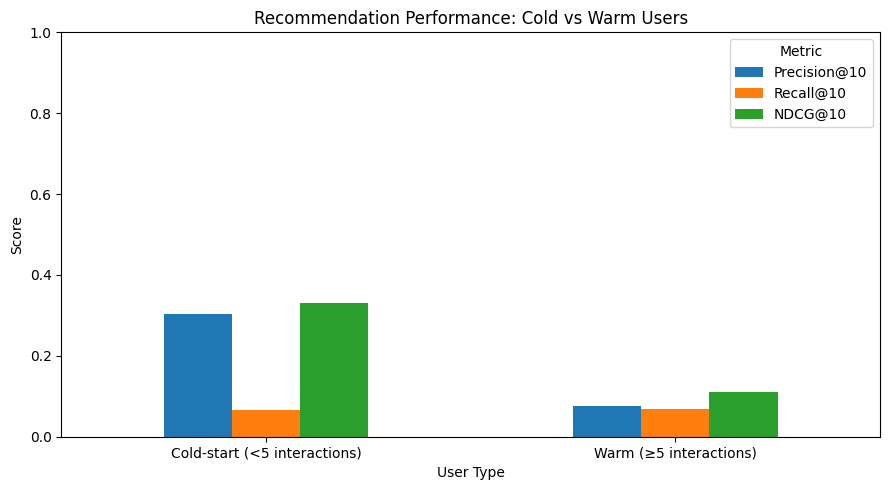

In [93]:
ax = final_results.set_index(
    'User Type'
).plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title(
    'Recommendation Performance: Cold vs Warm Users'
)

plt.ylabel('Score')

plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend(
    title='Metric'
)

plt.tight_layout()

plt.show()

In [94]:
model_comparison = pd.DataFrame({
    'Model': [
        'Content-Based',
        'Hybrid'
    ],

    'Precision@10': [
        cold_results['precision@10'].mean(),
        cold_hybrid_results['precision@10'].mean()
    ],

    'Recall@10': [
        cold_results['recall@10'].mean(),
        cold_hybrid_results['recall@10'].mean()
    ],

    'NDCG@10': [
        cold_results['ndcg@10'].mean(),
        cold_hybrid_results['ndcg@10'].mean()
    ]
})

model_comparison

,Model,Precision@10,Recall@10,NDCG@10
0,Content-Based,0.072,0.010309,0.072779
1,Hybrid,0.304,0.065804,0.329633


In [95]:
print("Precision improvement:",
      cold_hybrid_precision -
      cold_results['precision@10'].mean())

print("Recall improvement:",
      cold_hybrid_recall -
      cold_results['recall@10'].mean())

print("NDCG improvement:",
      cold_hybrid_ndcg -
      cold_results['ndcg@10'].mean())

Precision improvement: 0.23199999999999998
Recall improvement: 0.05549508873195542
NDCG improvement: 0.25685361054267386


In [96]:
summary = pd.DataFrame({
    'Model': [
        'Content-Based',
        'Hybrid Cold-Start',
        'Hybrid Warm Users'
    ],

    'Precision@10': [
        cold_results['precision@10'].mean(),
        cold_hybrid_precision,
        warm_precision
    ],

    'Recall@10': [
        cold_results['recall@10'].mean(),
        cold_hybrid_recall,
        warm_recall
    ],

    'NDCG@10': [
        cold_results['ndcg@10'].mean(),
        cold_hybrid_ndcg,
        warm_ndcg
    ]
})

summary

,Model,Precision@10,Recall@10,NDCG@10
0,Content-Based,0.072,0.010309,0.072779
1,Hybrid Cold-Start,0.304,0.065804,0.329633
2,Hybrid Warm Users,0.077,0.067496,0.110246


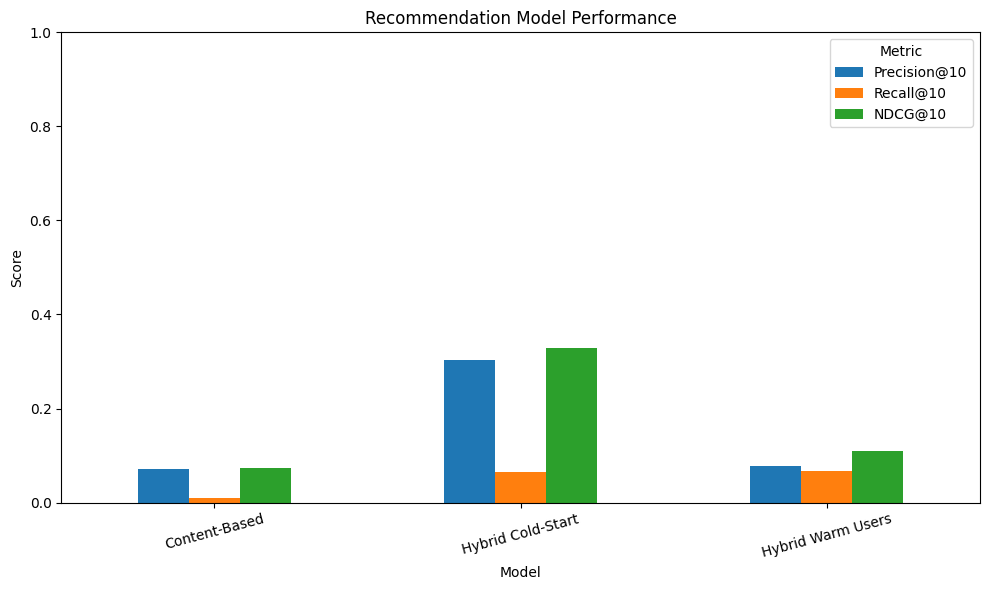

In [97]:
summary.set_index('Model').plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title(
    'Recommendation Model Performance'
)

plt.ylabel('Score')

plt.ylim(0, 1)

plt.xticks(rotation=15)

plt.legend(title='Metric')

plt.tight_layout()

plt.show()

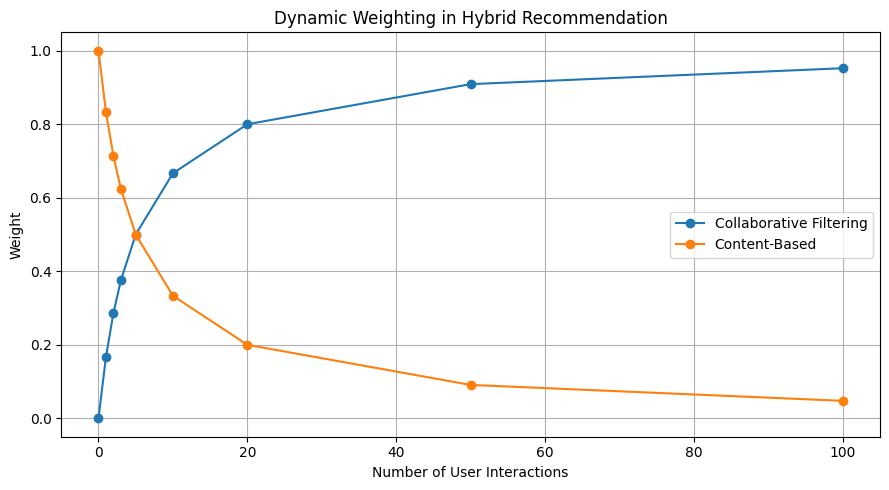

In [98]:
plt.figure(figsize=(9, 5))

plt.plot(
    interaction_values,
    weight_table['CF Weight'],
    marker='o',
    label='Collaborative Filtering'
)

plt.plot(
    interaction_values,
    weight_table['Content Weight'],
    marker='o',
    label='Content-Based'
)

plt.xlabel('Number of User Interactions')

plt.ylabel('Weight')

plt.title(
    'Dynamic Weighting in Hybrid Recommendation'
)

plt.legend()

plt.grid()

plt.tight_layout()

plt.show()